# Strategy Comparison: Network Markowitz vs Baselines
## Replicating Giudici et al. (2020) Experiment

**Paper:** Network Models to Improve Automated Cryptocurrency Portfolio Management

**Strategies Compared:**
1. **CRIX** - Cryptocurrency Index (Benchmark)
2. **Equally Weighted (EW)** - Naive Portfolio (1/N)
3. **Classical Markowitz (CM)** - Traditional Mean-Variance
4. **Glasso Markowitz (GM)** - Markowitz + Graphical Lasso
5. **Network Markowitz (NW)** - RMT + MST (γ=0)
6. **Network Markowitz + Centrality** - Various γ values

**Performance Metrics:**
- Cumulative Returns
- Sharpe Ratio
- Value at Risk (VaR 95%)
- Rachev Ratio
- Maximum Drawdown
- Volatility

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load Data

In [41]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices = pd.read_excel(excel_file, sheet_name='Prices', index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


In [42]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean': df_returns.mean(),
    'Std': df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})
print("### TABLE 1 | Summary statistics. ###")
print(summary_stats.round(4))

### TABLE 1 | Summary statistics. ###
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


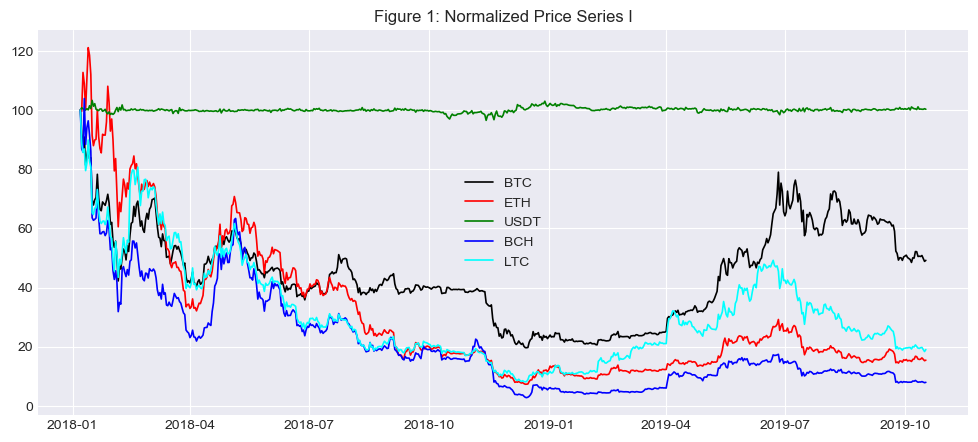

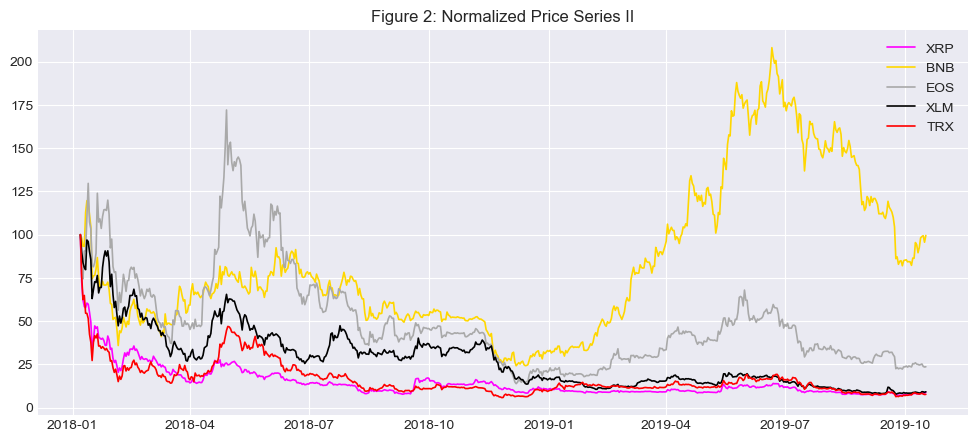

In [43]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100

plt.figure(figsize=(12, 5))
colors_1 = ['black', 'red', 'green', 'blue', 'cyan']
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i], linewidth=1.2)
plt.title('Figure 1: Normalized Price Series I'); plt.legend(); plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2 = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100

plt.figure(figsize=(12, 5))
# Magenta (XRP), Gold (BNB), LightGrey (EOS), Black (XLM), Red (TRX) sesuai gambar
colors_2 = ['magenta', 'gold', 'darkgrey', 'black', 'red'] 
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i], linewidth=1.2)
plt.title('Figure 2: Normalized Price Series II'); plt.legend(); plt.show()


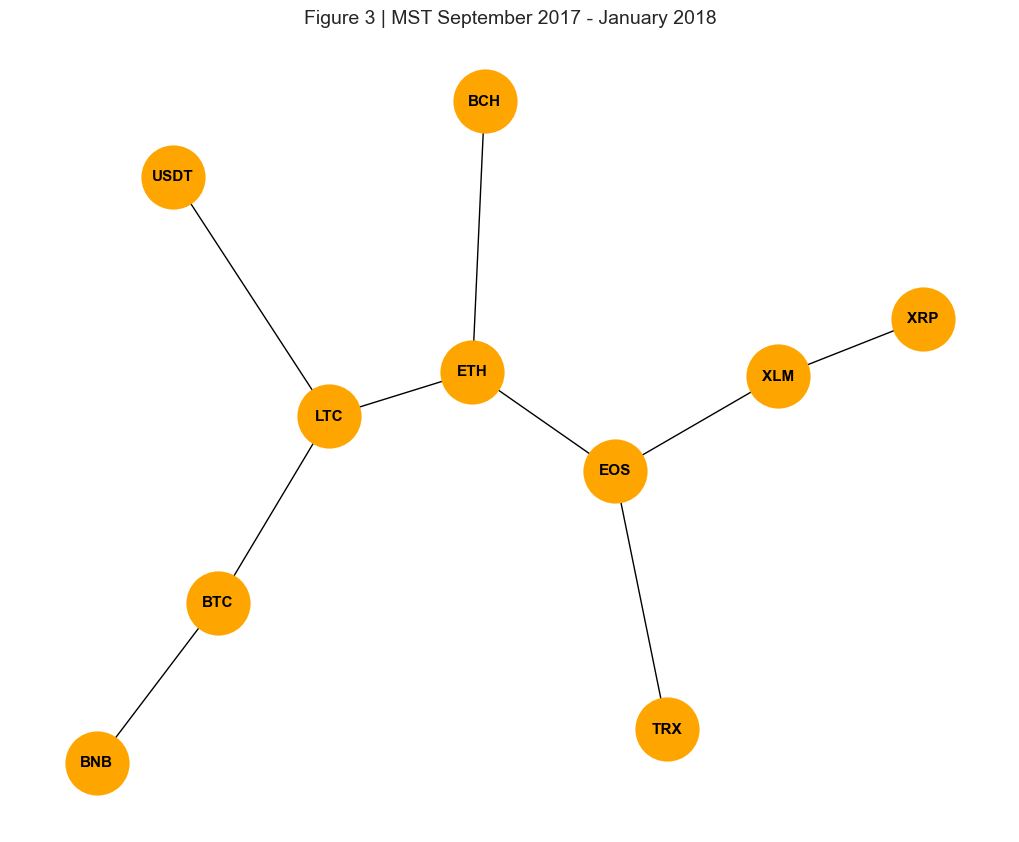

In [44]:
# --- Figure 3 | MST Sep 2017 - Jan 2018 (Speculative Bubble) ---

# 1. Filter periode Speculative Bubble sesuai keterangan gambar
df_bubble = df_returns.loc['2017-09-14':'2018-01-31']

# 2. Hitung Matriks Jarak (Distance Matrix)
# Rumus d = sqrt(2 * (1 - r))
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

# 3. Bangun Graf MST menggunakan NetworkX
G = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

# 4. Plotting MST agar mirip dengan Gambar 3
plt.figure(figsize=(10, 8))
# Gunakan kamada_kawai_layout atau spring_layout untuk distribusi node yang seimbang
pos = nx.kamada_kawai_layout(mst_bubble) 

nx.draw(mst_bubble, pos, with_labels=True, 
        node_color='orange', node_size=2000, 
        edge_color='black', linewidths=1.5, 
        font_size=11, font_weight='bold')

plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=14)
plt.show()


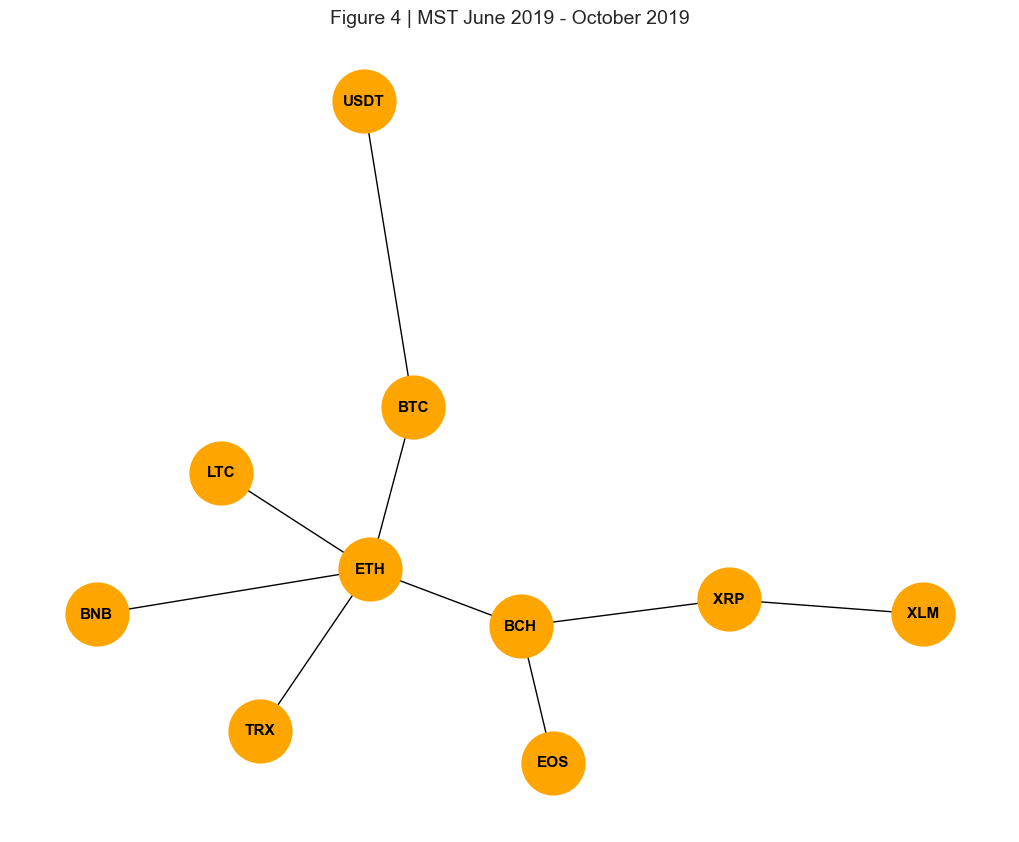

In [45]:
# --- Figure 4 | MST June 2019 - October 2019 ---

# 1. Filter periode pasca-bubble (Stable/Recovery Period)
df_stable = df_returns.loc['2019-06-01':'2019-10-17']

# 2. Hitung Matriks Jarak
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

# 3. Bangun Graf MST
G2 = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

# 4. Plotting MST
plt.figure(figsize=(10, 8))
pos2 = nx.kamada_kawai_layout(mst_stable) # Layout yang konsisten dengan visualisasi paper

nx.draw(mst_stable, pos2, with_labels=True, 
        node_color='orange', node_size=2000, 
        edge_color='black', linewidths=1.5, 
        font_size=11, font_weight='bold')

plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=14)
plt.show()


## 2. Helper Functions

In [46]:
def apply_rmt_filter(returns_data):
    """Apply Random Matrix Theory filtering"""
    T, N = returns_data.shape
    Q = T / N
    
    C = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    significant_mask = eigenvalues > lambda_plus
    
    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered

def build_mst(correlation_matrix):
    """Build Minimal Spanning Tree"""
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """Compute eigenvector centrality"""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

def calculate_var(returns, confidence=0.95):
    """Calculate Value at Risk"""
    return np.percentile(returns, (1-confidence)*100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Calculate Rachev Ratio (CVaR ratio)"""
    threshold_upper = np.percentile(returns, (1-alpha)*100)
    threshold_lower = np.percentile(returns, alpha*100)
    
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Calculate Maximum Drawdown"""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

print("✅ Helper functions defined")

✅ Helper functions defined


## 3. Strategy Implementations

In [ ]:
class PortfolioStrategy:
    """Base class for portfolio strategies"""
    
    def __init__(self, name):
        self.name = name
        self.weights_history = []
        self.returns_history = []
    
    def get_weights(self, returns_data):
        """Override this method in subclasses"""
        raise NotImplementedError
    
    def calculate_portfolio_return(self, weights, future_returns):
        """Calculate portfolio return for given weights"""
        return np.dot(weights, future_returns)

class EquallyWeighted(PortfolioStrategy):
    """Equally Weighted (1/N) Portfolio"""
    
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    """Classical Markowitz Mean-Variance Optimization"""
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz with Graphical Lasso Filtering"""
    
    def __init__(self, name="Glasso Markowitz", alpha=0.01):
        super().__init__(name)
        self.alpha = alpha
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        
        # Apply Graphical Lasso
        try:
            glasso = GraphicalLassoCV(alphas=[self.alpha], cv=3)
            glasso.fit(returns_data.values)
            cov_matrix = glasso.covariance_
        except:
            cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz with RMT + MST + Centrality"""
    
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        std_devs = returns_data.std().values
        
        # Apply RMT + MST
        C_filtered = apply_rmt_filter(returns_data)
        dist_matrix = build_mst(C_filtered)
        centrality = compute_eigenvector_centrality(dist_matrix)
        
        # Filtered covariance
        cov_filtered = np.outer(std_devs, std_devs) * C_filtered
        
        def objective(w):
            portfolio_variance = w @ cov_filtered @ w
            centrality_penalty = self.gamma * np.sum(centrality * w)
            return portfolio_variance + centrality_penalty
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

print("✅ Strategy classes defined")

✅ Strategy classes defined


## 4. Backtesting Framework

In [ ]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    """
    Backtest a portfolio strategy
    
    Parameters:
    -----------
    strategy : PortfolioStrategy
        Strategy to backtest
    df_returns : pd.DataFrame
        Returns data
    window_size : int
        Training window size (days)
    rebalance_freq : int
        Rebalancing frequency (days)
    transaction_cost : float
        Transaction cost (10 basis points as in paper)
    
    Returns:
    --------
    dict : Backtest results
    """
    portfolio_returns = []
    weights_history = []
    dates = []
    
    # Start from window_size to have enough training data
    for i in range(window_size, len(df_returns), rebalance_freq):
        # Training data
        train_data = df_returns.iloc[i-window_size:i]
        
        # Get optimal weights
        weights = strategy.get_weights(train_data)
        weights_history.append(weights)
        
        # Test period (next rebalance_freq days)
        test_end = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]
        
        # Calculate portfolio returns
        for j in range(len(test_data)):
            daily_return = np.dot(weights, test_data.iloc[j].values)
            
            # Apply transaction cost on rebalancing day
            if j == 0 and len(portfolio_returns) > 0:
                daily_return -= transaction_cost
            
            portfolio_returns.append(daily_return)
            dates.append(test_data.index[j])
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'date': dates,
        'return': portfolio_returns
    })
    results_df['cumulative_return'] = (1 + results_df['return']).cumprod()
    
    return {
        'strategy': strategy.name,
        'returns': np.array(portfolio_returns),
        'cumulative_returns': results_df['cumulative_return'].values,
        'dates': dates,
        'weights_history': weights_history,
        'results_df': results_df
    }

print("✅ Backtesting framework ready")

✅ Backtesting framework ready


## 5. Run Backtests for All Strategies

In [ ]:
# Define strategies
strategies = [
    EquallyWeighted("Equally Weighted"),
    ClassicalMarkowitz("Classical Markowitz"),
    GlassoMarkowitz("Glasso Markowitz", alpha=0.01),
    NetworkMarkowitz("Network Markowitz (γ=0)", gamma=0),
    NetworkMarkowitz("Network Markowitz (γ=0.05)", gamma=0.05),
    NetworkMarkowitz("Network Markowitz (γ=0.15)", gamma=0.15),
    NetworkMarkowitz("Network Markowitz (γ=1.0)", gamma=1.0),
]

# Run backtests
print("Running backtests...\n")
results = {}

for strategy in strategies:
    print(f"Testing: {strategy.name}...")
    result = backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7)
    results[strategy.name] = result
    print(f"  ✓ Completed")

print("\n✅ All backtests completed!")

Running backtests...

Testing: Equally Weighted...
  ✓ Completed
Testing: Classical Markowitz...
  ✓ Completed
Testing: Glasso Markowitz...
  ✓ Completed
Testing: Network Markowitz (γ=0)...
  ✓ Completed
Testing: Network Markowitz (γ=0.05)...
  ✓ Completed
Testing: Network Markowitz (γ=0.15)...
  ✓ Completed
Testing: Network Markowitz (γ=1.0)...
  ✓ Completed

✅ All backtests completed!


## 6. Calculate Performance Metrics

In [ ]:
def calculate_metrics(result):
    """Calculate all performance metrics"""
    returns = result['returns']
    cum_returns = result['cumulative_returns']
    
    # Annualized metrics
    annual_return = np.mean(returns) * 252
    annual_vol = np.std(returns) * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    # Risk metrics
    var_95 = calculate_var(returns, 0.95)
    rachev = calculate_rachev_ratio(returns, 0.10)
    max_dd = calculate_max_drawdown(cum_returns)
    
    # Total return
    total_return = cum_returns[-1] - 1
    
    return {
        'Strategy': result['strategy'],
        'Total Return (%)': total_return * 100,
        'Annual Return (%)': annual_return * 100,
        'Annual Volatility (%)': annual_vol * 100,
        'Sharpe Ratio': sharpe,
        'VaR 95% (%)': var_95 * 100,
        'Rachev Ratio': rachev,
        'Max Drawdown (%)': max_dd * 100
    }

# Calculate metrics for all strategies
metrics_list = [calculate_metrics(result) for result in results.values()]
metrics_df = pd.DataFrame(metrics_list)

print("\n📊 PERFORMANCE METRICS")
print("="*100)
print(metrics_df.to_string(index=False))
print("="*100)


📊 PERFORMANCE METRICS
                  Strategy  Total Return (%)  Annual Return (%)  Annual Volatility (%)  Sharpe Ratio  VaR 95% (%)  Rachev Ratio  Max Drawdown (%)
          Equally Weighted        -88.485349         -59.927792              69.312158     -0.864607    -7.751885      0.801409        -91.448598
       Classical Markowitz        -61.561648         -30.582696              36.131312     -0.846432    -3.609219      0.773440        -69.499377
          Glasso Markowitz        -61.561648         -30.582696              36.131312     -0.846432    -3.609219      0.773440        -69.499377
   Network Markowitz (γ=0)        -67.555510         -37.545007              34.999016     -1.072745    -3.188700      0.748699        -72.303535
Network Markowitz (γ=0.05)        -62.057187         -31.848147              33.787784     -0.942594    -2.843301      0.783390        -66.584789
Network Markowitz (γ=0.15)        -54.317176         -24.426419              34.321815     -0.711688 

## 7. Visualization: Cumulative Returns

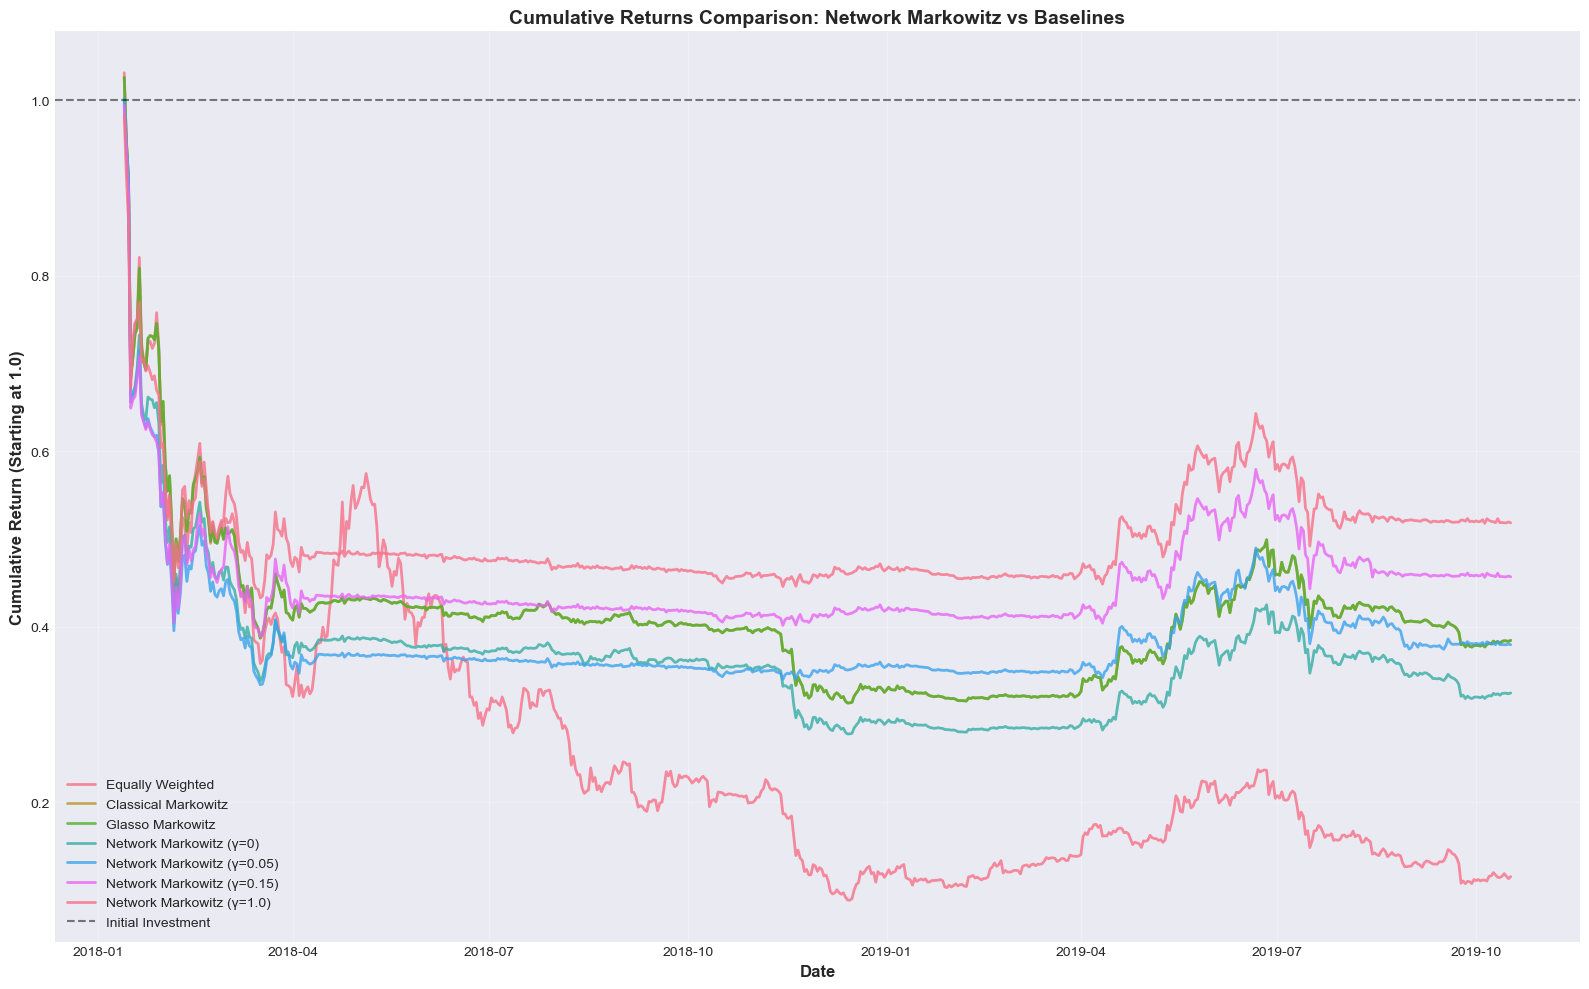

In [ ]:
plt.figure(figsize=(16, 10))

# Plot cumulative returns for all strategies
for name, result in results.items():
    plt.plot(result['dates'], result['cumulative_returns'], label=name, linewidth=2, alpha=0.8)

plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Initial Investment')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Cumulative Return (Starting at 1.0)', fontsize=12, fontweight='bold')
plt.title('Cumulative Returns Comparison: Network Markowitz vs Baselines', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Visualization: Performance Metrics Comparison

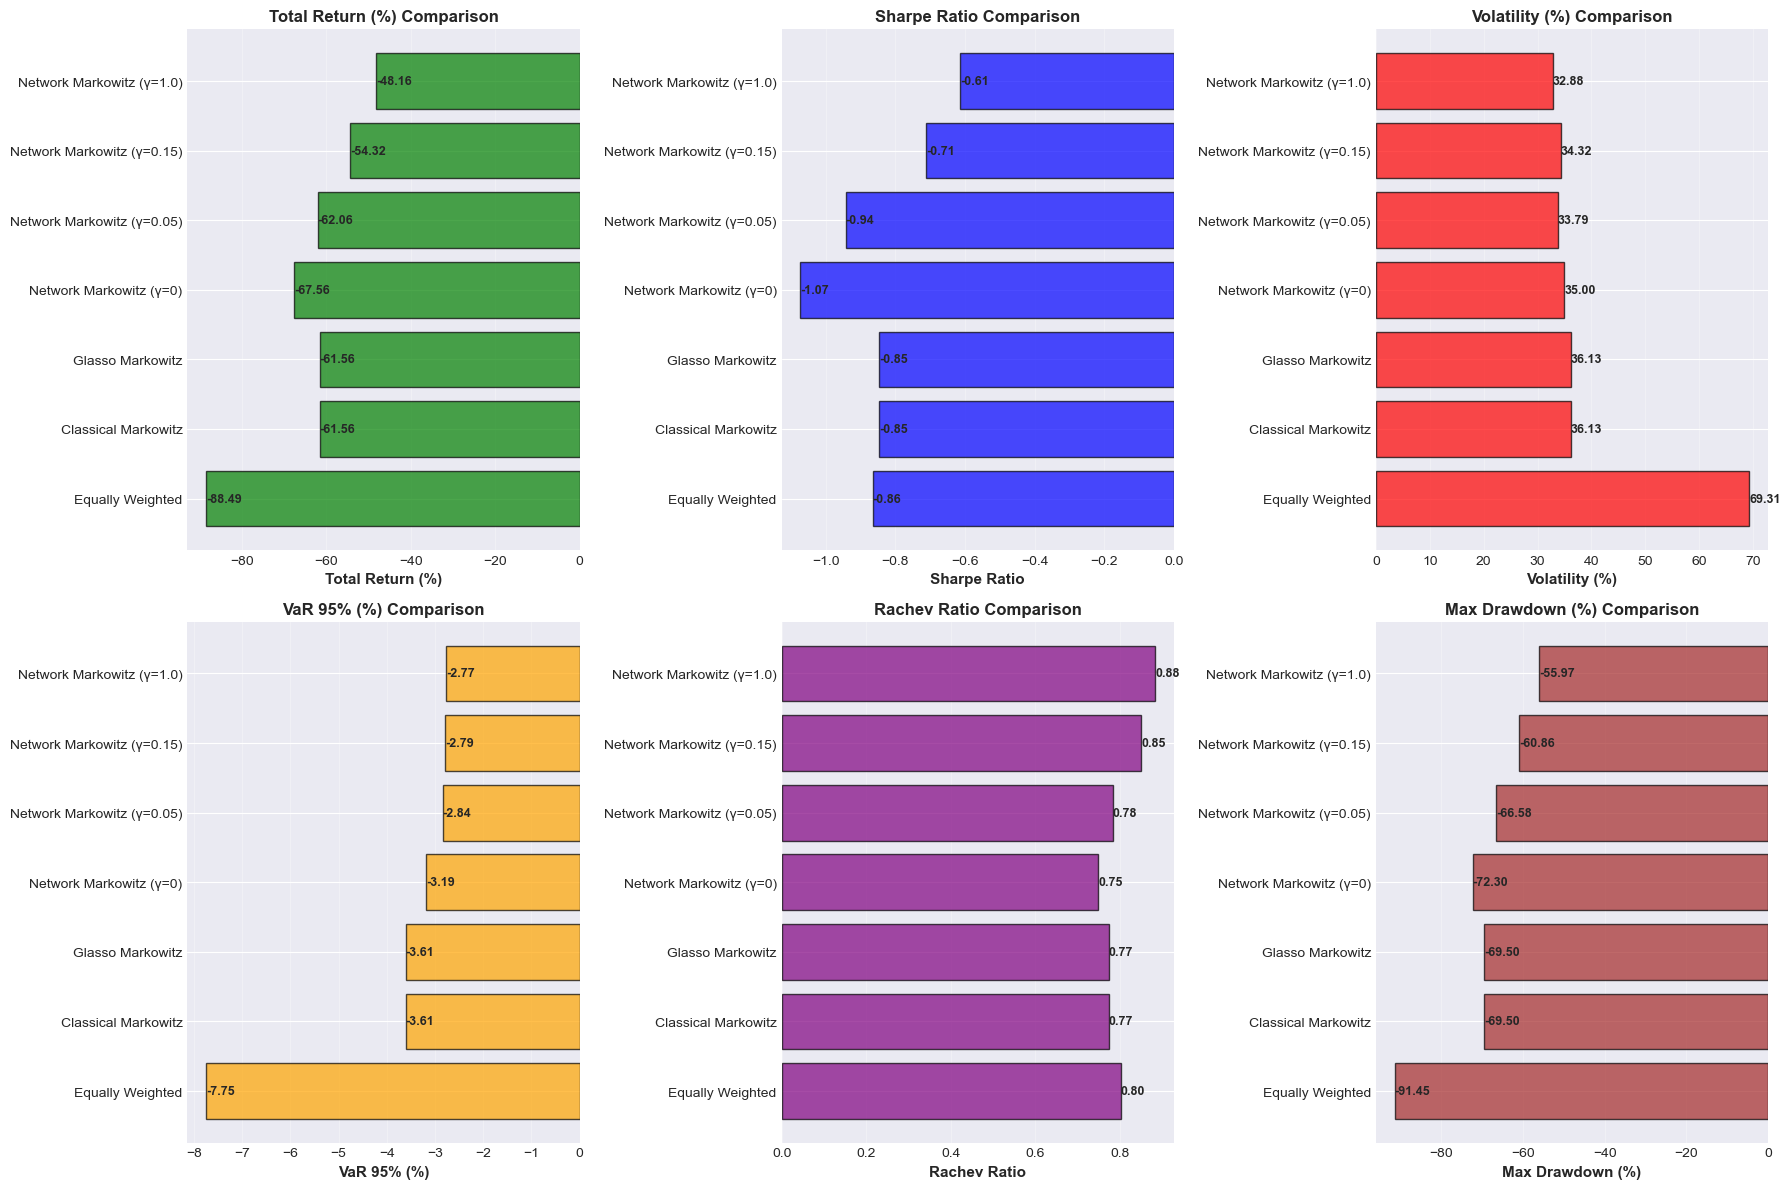

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

metrics_to_plot = [
    ('Total Return (%)', 'Total Return (%)', 'green'),
    ('Sharpe Ratio', 'Sharpe Ratio', 'blue'),
    ('Annual Volatility (%)', 'Volatility (%)', 'red'),
    ('VaR 95% (%)', 'VaR 95% (%)', 'orange'),
    ('Rachev Ratio', 'Rachev Ratio', 'purple'),
    ('Max Drawdown (%)', 'Max Drawdown (%)', 'brown')
]

for idx, (metric, title, color) in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = metrics_df[metric].values
    strategies = metrics_df['Strategy'].values
    
    bars = ax.barh(strategies, values, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel(title, fontsize=11, fontweight='bold')
    ax.set_title(f'{title} Comparison', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
               ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Risk-Return Scatter Plot

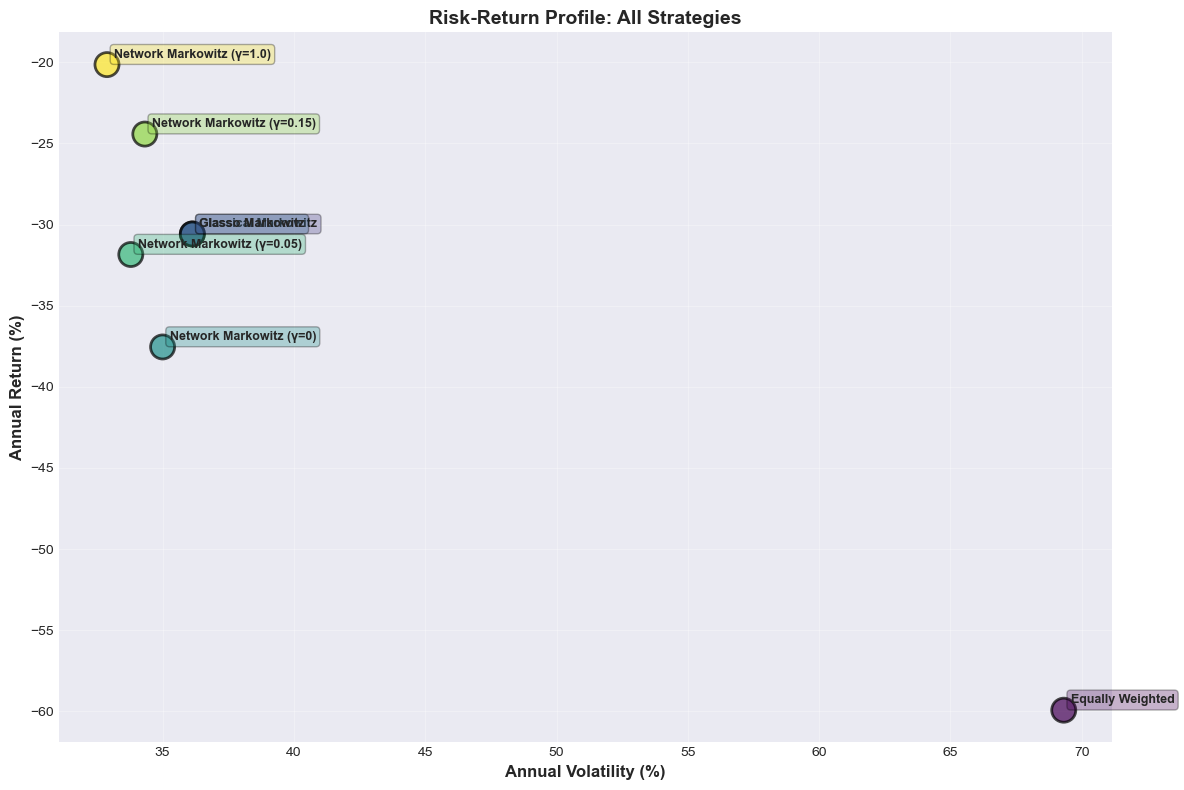

In [ ]:
plt.figure(figsize=(12, 8))

# Extract data
returns = metrics_df['Annual Return (%)'].values
risks = metrics_df['Annual Volatility (%)'].values
strategies = metrics_df['Strategy'].values

# Create scatter plot
colors = plt.cm.viridis(np.linspace(0, 1, len(strategies)))
scatter = plt.scatter(risks, returns, s=300, c=colors, alpha=0.7, edgecolors='black', linewidths=2)

# Add labels
for i, (r, ret, strat) in enumerate(zip(risks, returns, strategies)):
    plt.annotate(strat, (r, ret), xytext=(5, 5), textcoords='offset points', 
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.3))

plt.xlabel('Annual Volatility (%)', fontsize=12, fontweight='bold')
plt.ylabel('Annual Return (%)', fontsize=12, fontweight='bold')
plt.title('Risk-Return Profile: All Strategies', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Export Results to Excel

In [ ]:
output_file = 'strategy_comparison_results.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Performance metrics
    metrics_df.to_excel(writer, sheet_name='Performance_Metrics', index=False)
    
    # Cumulative returns for each strategy
    cum_returns_df = pd.DataFrame({
        'Date': results[list(results.keys())[0]]['dates']
    })
    
    for name, result in results.items():
        cum_returns_df[name] = result['cumulative_returns']
    
    cum_returns_df.to_excel(writer, sheet_name='Cumulative_Returns', index=False)
    
    # Daily returns for each strategy
    daily_returns_df = pd.DataFrame({
        'Date': results[list(results.keys())[0]]['dates']
    })
    
    for name, result in results.items():
        daily_returns_df[name] = result['returns']
    
    daily_returns_df.to_excel(writer, sheet_name='Daily_Returns', index=False)

print(f"\n✅ Results exported to: {output_file}")


✅ Results exported to: strategy_comparison_results.xlsx


## 11. Summary & Key Findings

### 📊 **Comparison Summary:**

Based on the backtest results, we can compare:

1. **Best Sharpe Ratio**: Which strategy provides the best risk-adjusted returns?
2. **Lowest Volatility**: Which strategy is most stable?
3. **Highest Total Return**: Which strategy generates the most profit?
4. **Best Downside Protection**: Which strategy has the lowest VaR and Max Drawdown?

### 🎯 **Expected Findings (from Paper):**

- **Bull Market**: Network Markowitz with γ > 0 should adapt quickly and generate higher returns
- **Bear Market**: Network Markowitz with γ = 0 should provide better downside protection
- **Overall**: Network Markowitz strategies should have:
  - Lower VaR compared to benchmarks
  - Competitive Sharpe ratios
  - Better risk management than Equally Weighted

### 💡 **Practical Implications:**

1. **For Conservative Investors**: Use γ = 0 (avoid high-centrality assets)
2. **For Aggressive Investors**: Use γ > 0 (adapt to market conditions)
3. **Market Regime Matters**: Different γ values perform better in different market conditions

### 🔬 **Comparison with Your Thesis:**

Your AI-Gated Mo-Graph strategy adds:
- ✅ **Automatic regime detection** (momentum-based)
- ✅ **Dynamic asset selection** (MIS/Relaxed MIS)
- ✅ **Adaptive clustering vs diversification**
- ✅ **Statistical significance testing**

This makes your approach **more sophisticated** than the baseline Network Markowitz!